In [30]:
import os
from pathlib import Path
import json

import numpy as np
import mne
import torch
import matplotlib.pyplot as plt

In [5]:
base = Path("/media/skojima/41e27c66-4999-42a0-b36f-cc19d7881326/david/attribution")

# Dreyer2023

In [44]:


def plot_temporal_saliency(dataset, model, window, subject=None, target=0, ax=None):

    if ax is None:
        fig, ax = plt.subplots()

    files = os.listdir(base)
    files_to_load = []
    for file in files:
        if window in file and dataset in file and model in file:
            if subject is not None:
                if f"{subject}.pt" in file:
                    files_to_load.append(file)
            else:
                files_to_load.append(file)

    saliency_list = []

    for file in files_to_load:
        data = torch.load(base/file, weights_only=True)
        saliency = data[target]["saliency"]

        saliency_list.append(saliency)

    saliency = torch.concat(saliency_list, dim=0)

    saliency_temporal = saliency.mean((0,1))
    saliency_temporal = saliency_temporal / saliency_temporal.sum() * 100


    ax.plot(saliency_temporal)
    ax.set_xlabel("Time [samples]")
    ax.set_ylabel("Saliency in %")


def plot_spatial_saliency(dataset, model, window, subject=None, target=0, montage="standard_1020", ax=None):

    if ax is None:
        fig, ax = plt.subplots()

    with open(f"../Dataset/{dataset}/meta_data.json", "r") as f:
        info = json.load(f)
    ch_names = info["ch_names"]

    files = os.listdir(base)
    files_to_load = []
    for file in files:
        if window in file and dataset in file and model in file:
            if subject is not None:
                if f"{subject}.pt" in file:
                    files_to_load.append(file)
            else:
                files_to_load.append(file)

    saliency_list = []

    for file in files_to_load:
        data = torch.load(base/file, weights_only=True)
        saliency = data[target]["saliency"]

        saliency_list.append(saliency)

    saliency = torch.concat(saliency_list, dim=0)

    saliency_spatial = saliency.mean((0,2))
    saliency_spatial = saliency_spatial / saliency_spatial.sum() * 100

    #info = mne.create_info(ch_names, 1000.0, "eeg")
    #info.set_montage("standard_1020")
    #mne.viz.plot_topomap(saliency_spatial, info, axes=ax, show=False, extrapolate="local")

    montage = mne.channels.make_standard_montage(montage)
    ch_pos = montage.get_positions()["ch_pos"]
    ch_pos = np.array([ch_pos[ch_name][:2] for ch_name in ch_names])

    im , _  = mne.viz.plot_topomap(saliency_spatial, ch_pos, names=ch_names, cmap="Reds", axes=ax, show=False)

    cbar = plt.colorbar(im, ax=ax, shrink=0.8)
    cbar.set_label("Saliency in %", rotation=270, labelpad=30)



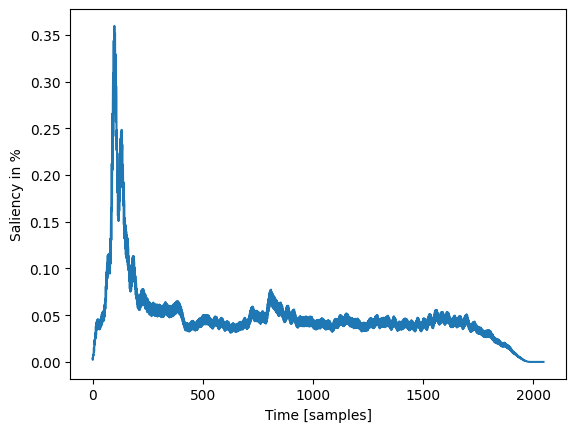

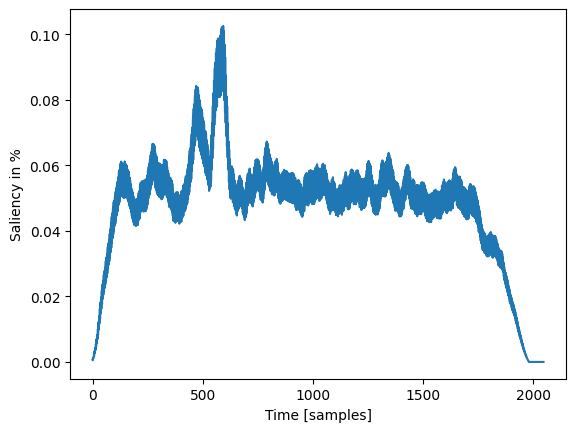

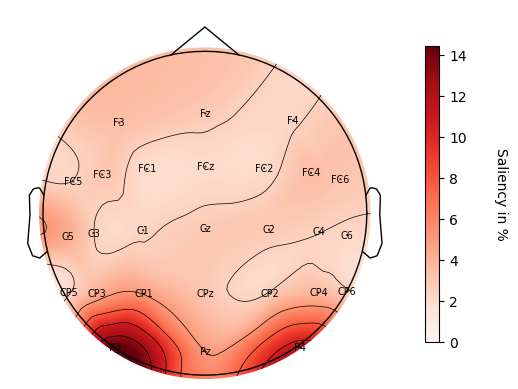

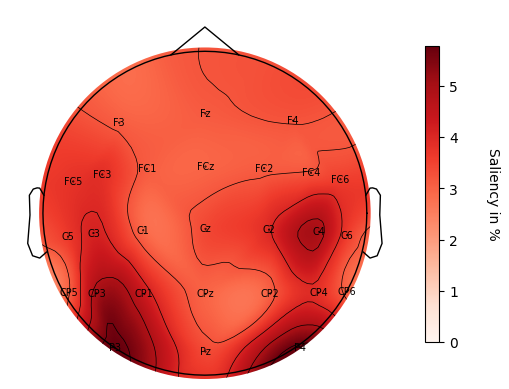

In [40]:
dataset = "Dreyer2023"
model = "Deep4Net"
windows = ["w_00_40", "w_05_45"]

plot_temporal_saliency(dataset, model, windows[0], subject=1, target=1)
plot_temporal_saliency(dataset, model, windows[1], subject=1, target=1)

plot_spatial_saliency(dataset, model, windows[0], subject=1, target=1)
plot_spatial_saliency(dataset, model, windows[1], subject=1, target=1)


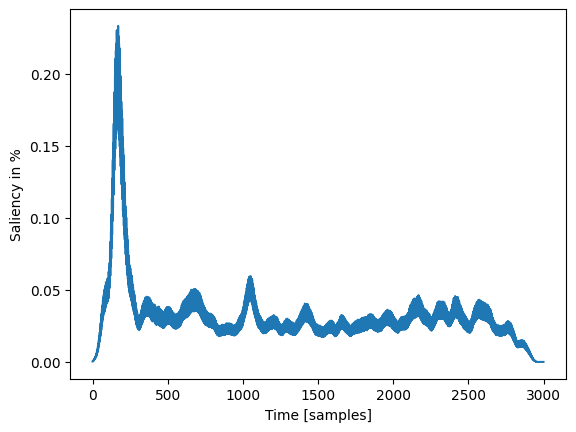

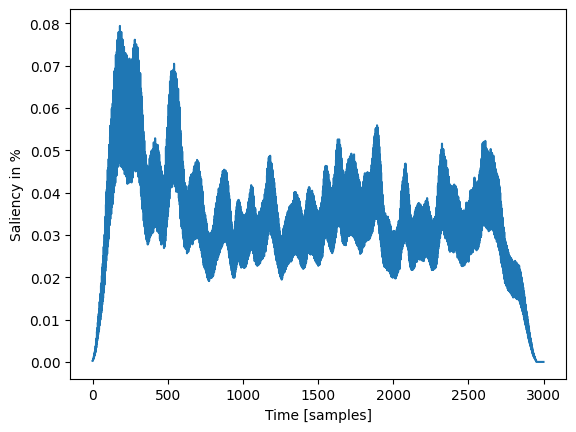

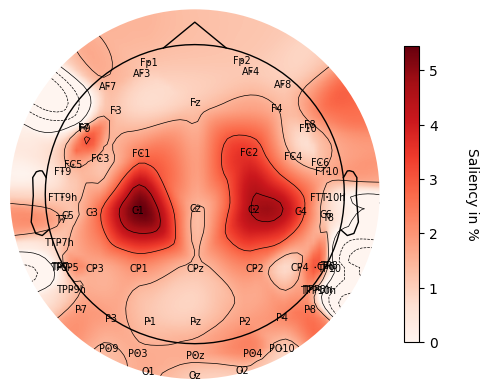

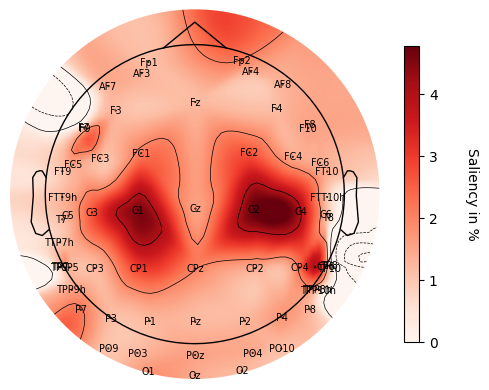

In [43]:
dataset = "Lee2019_MI"
model = "Deep4Net"
windows = ["w_00_30", "w_05_35"]

plot_temporal_saliency(dataset, model, windows[0], subject=1, target=1)
plot_temporal_saliency(dataset, model, windows[1], subject=1, target=1)

plot_spatial_saliency(dataset, model, windows[0], subject=1, target=1, montage="standard_1005")
plot_spatial_saliency(dataset, model, windows[1], subject=1, target=1, montage="standard_1005")
